# Module 1: Data Cleaning & Exploratory Data Analysis

**Objective:** Load the Olist Brazilian E-Commerce dataset, understand its structure, clean the data, and perform initial exploratory analysis.

**Tools:** Pandas, NumPy, Matplotlib, Seaborn

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

DATA_DIR = Path("../data")
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

## 1.1 Load All Datasets

In [2]:
customers = pd.read_csv(DATA_DIR / "olist_customers_dataset.csv")
orders = pd.read_csv(DATA_DIR / "olist_orders_dataset.csv")
order_items = pd.read_csv(DATA_DIR / "olist_order_items_dataset.csv")
payments = pd.read_csv(DATA_DIR / "olist_order_payments_dataset.csv")
reviews = pd.read_csv(DATA_DIR / "olist_order_reviews_dataset.csv")
products = pd.read_csv(DATA_DIR / "olist_products_dataset.csv")
sellers = pd.read_csv(DATA_DIR / "olist_sellers_dataset.csv")
category_translation = pd.read_csv(DATA_DIR / "product_category_name_translation.csv")

datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers,
    "category_translation": category_translation,
}

for name, df in datasets.items():
    print(f"{name:>25s}: {df.shape[0]:>8,} rows × {df.shape[1]:>2} cols")

                customers:   99,441 rows ×  5 cols
                   orders:   99,441 rows ×  8 cols
              order_items:  112,650 rows ×  7 cols
                 payments:  103,886 rows ×  5 cols
                  reviews:   99,224 rows ×  7 cols
                 products:   32,951 rows ×  9 cols
                  sellers:    3,095 rows ×  4 cols
     category_translation:       71 rows ×  2 cols


## 1.2 Schema Overview & Data Types

In [3]:
for name, df in datasets.items():
    print(f"\n{'='*60}")
    print(f"  {name.upper()}")
    print(f"{'='*60}")
    print(df.dtypes.to_string())
    print(f"\nShape: {df.shape}")
    display(df.head(3))


  CUSTOMERS
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object

Shape: (99441, 5)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP



  ORDERS
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object

Shape: (99441, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00



  ORDER_ITEMS
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64

Shape: (112650, 7)


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0



  SELLERS
seller_id                 object
seller_zip_code_prefix     int64
seller_city               object
seller_state              object

Shape: (3095, 4)


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ



  CATEGORY_TRANSLATION
product_category_name            object
product_category_name_english    object

Shape: (71, 2)


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto


## 1.3 Missing Values Analysis

In [4]:
missing_summary = []
for name, df in datasets.items():
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    for col in df.columns:
        if missing[col] > 0:
            missing_summary.append({
                "dataset": name,
                "column": col,
                "missing_count": missing[col],
                "missing_pct": missing_pct[col],
            })

missing_df = pd.DataFrame(missing_summary).sort_values("missing_pct", ascending=False)
print(f"Total columns with missing values: {len(missing_df)}")
display(missing_df)

Total columns with missing values: 13


,dataset,column,missing_count,missing_pct
3,reviews,review_comment_title,87656,88.34
4,reviews,review_comment_message,58247,58.70
2,orders,order_delivered_customer_date,2965,2.98
5,products,product_category_name,610,1.85
6,products,product_name_lenght,610,1.85
7,products,product_description_lenght,610,1.85
8,products,product_photos_qty,610,1.85
1,orders,order_delivered_carrier_date,1783,1.79
0,orders,order_approved_at,160,0.16
9,products,product_weight_g,2,0.01


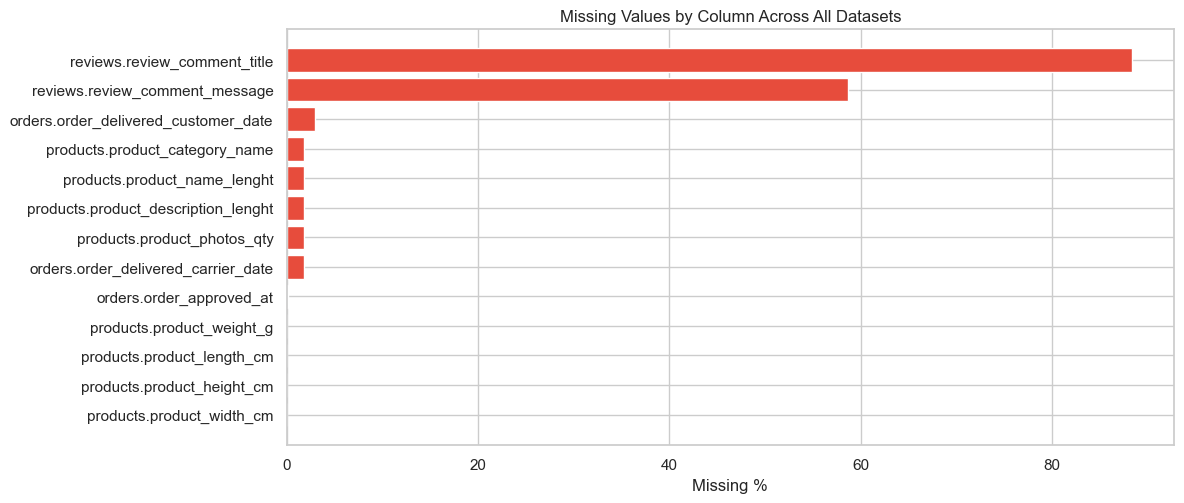

In [5]:
if not missing_df.empty:
    fig, ax = plt.subplots(figsize=(12, max(4, len(missing_df) * 0.4)))
    labels = missing_df["dataset"] + "." + missing_df["column"]
    ax.barh(labels, missing_df["missing_pct"], color="#e74c3c", edgecolor="white")
    ax.set_xlabel("Missing %")
    ax.set_title("Missing Values by Column Across All Datasets")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "missing_values.png", bbox_inches="tight")
    plt.show()

## 1.4 Data Cleaning

In [6]:
datetime_cols = {
    "orders": [
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ],
    "order_items": ["shipping_limit_date"],
    "reviews": ["review_creation_date", "review_answer_timestamp"],
}

for ds_name, cols in datetime_cols.items():
    df = datasets[ds_name]
    for col in cols:
        df[col] = pd.to_datetime(df[col], errors="coerce")
        print(f"Converted {ds_name}.{col} → datetime64")

orders = datasets["orders"]
order_items = datasets["order_items"]
reviews = datasets["reviews"]

Converted orders.order_purchase_timestamp → datetime64
Converted orders.order_approved_at → datetime64
Converted orders.order_delivered_carrier_date → datetime64
Converted orders.order_delivered_customer_date → datetime64
Converted orders.order_estimated_delivery_date → datetime64
Converted order_items.shipping_limit_date → datetime64
Converted reviews.review_creation_date → datetime64
Converted reviews.review_answer_timestamp → datetime64


In [7]:
products = products.merge(category_translation, on="product_category_name", how="left")
products["product_category_name_english"].fillna("other", inplace=True)
print(f"Products with English category names: {products['product_category_name_english'].notna().sum():,}")
products.head(3)

Products with English category names: 32,951


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure


In [8]:
products["product_weight_g"].fillna(products["product_weight_g"].median(), inplace=True)
products["product_length_cm"].fillna(products["product_length_cm"].median(), inplace=True)
products["product_height_cm"].fillna(products["product_height_cm"].median(), inplace=True)
products["product_width_cm"].fillna(products["product_width_cm"].median(), inplace=True)
products["product_name_lenght"].fillna(0, inplace=True)
products["product_description_lenght"].fillna(0, inplace=True)
products["product_photos_qty"].fillna(0, inplace=True)

print(f"Products missing values after cleaning: {products.isnull().sum().sum()}")

Products missing values after cleaning: 610


## 1.5 Build Master Dataset

In [9]:
df = (
    orders
    .merge(customers, on="customer_id", how="left")
    .merge(order_items, on="order_id", how="left")
    .merge(payments, on="order_id", how="left")
    .merge(products, on="product_id", how="left")
    .merge(sellers, on="seller_id", how="left")
)

print(f"Master dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Master dataset shape: (118434, 34)
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'seller_zip_code_prefix', 'seller_city', 'seller_state']


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,housewares,9350.0,maua,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,housewares,9350.0,maua,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,housewares,9350.0,maua,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,31570.0,belo horizonte,SP
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,232.0,1.0,420.0,24.0,19.0,21.0,auto,14840.0,guariba,SP


In [10]:
delivered = df[df["order_status"] == "delivered"].copy()
delivered["delivery_days"] = (
    delivered["order_delivered_customer_date"] - delivered["order_purchase_timestamp"]
).dt.days
delivered["delay_days"] = (
    delivered["order_delivered_customer_date"] - delivered["order_estimated_delivery_date"]
).dt.days

print(f"Delivered orders: {delivered.shape[0]:,}")
print(f"Avg delivery time: {delivered['delivery_days'].mean():.1f} days")
print(f"Avg delay: {delivered['delay_days'].mean():.1f} days (negative = early)")

Delivered orders: 115,038
Avg delivery time: 12.0 days
Avg delay: -12.0 days (negative = early)


## 1.6 Exploratory Data Analysis

=== ORDER STATUS DISTRIBUTION ===
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


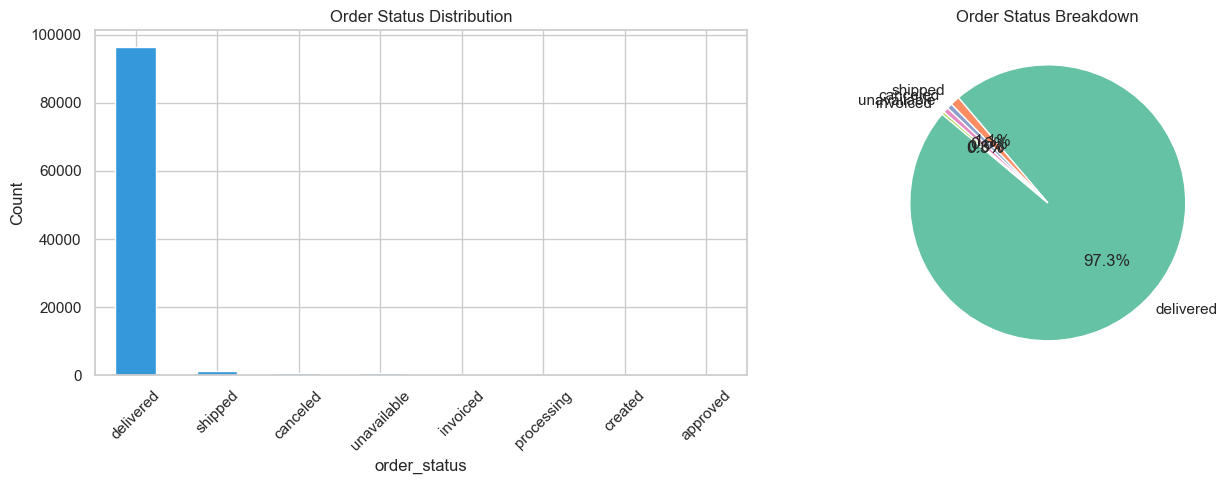

In [11]:
print("=== ORDER STATUS DISTRIBUTION ===")
status_counts = orders["order_status"].value_counts()
print(status_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

status_counts.plot(kind="bar", ax=axes[0], color="#3498db", edgecolor="white")
axes[0].set_title("Order Status Distribution")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

top_statuses = status_counts.head(5)
axes[1].pie(
    top_statuses.values,
    labels=top_statuses.index,
    autopct="%1.1f%%",
    colors=sns.color_palette("Set2", len(top_statuses)),
    startangle=140,
)
axes[1].set_title("Order Status Breakdown")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "order_status_distribution.png", bbox_inches="tight")
plt.show()

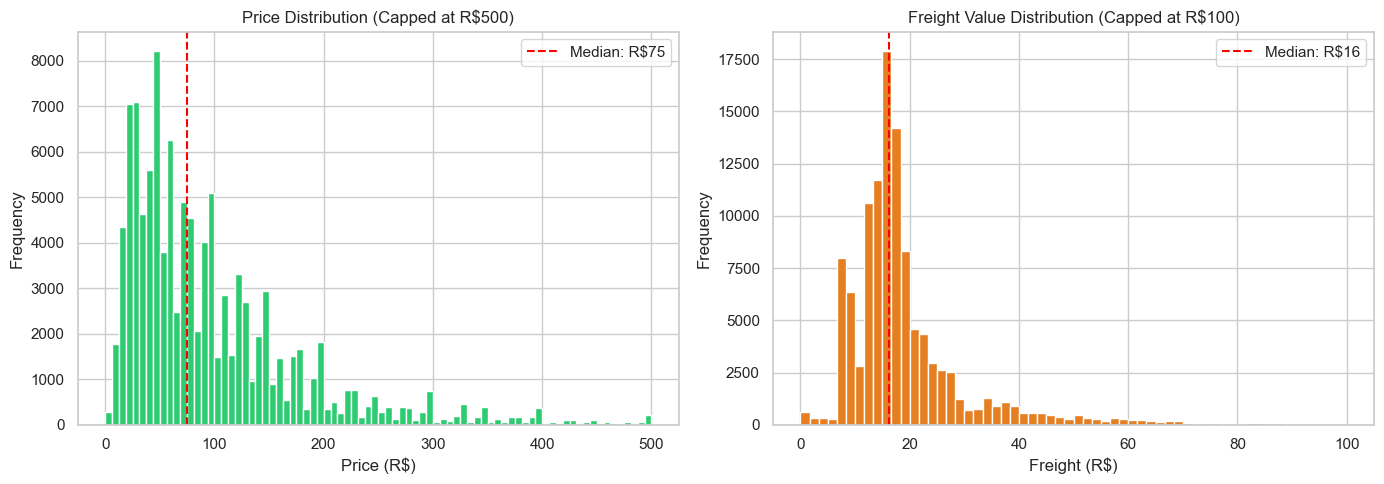

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(order_items["price"], bins=80, color="#2ecc71", edgecolor="white", range=(0, 500))
axes[0].set_title("Price Distribution (Capped at R$500)")
axes[0].set_xlabel("Price (R$)")
axes[0].set_ylabel("Frequency")
axes[0].axvline(order_items["price"].median(), color="red", linestyle="--", label=f"Median: R${order_items['price'].median():.0f}")
axes[0].legend()

axes[1].hist(order_items["freight_value"], bins=60, color="#e67e22", edgecolor="white", range=(0, 100))
axes[1].set_title("Freight Value Distribution (Capped at R$100)")
axes[1].set_xlabel("Freight (R$)")
axes[1].set_ylabel("Frequency")
axes[1].axvline(order_items["freight_value"].median(), color="red", linestyle="--", label=f"Median: R${order_items['freight_value'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "price_freight_distribution.png", bbox_inches="tight")
plt.show()

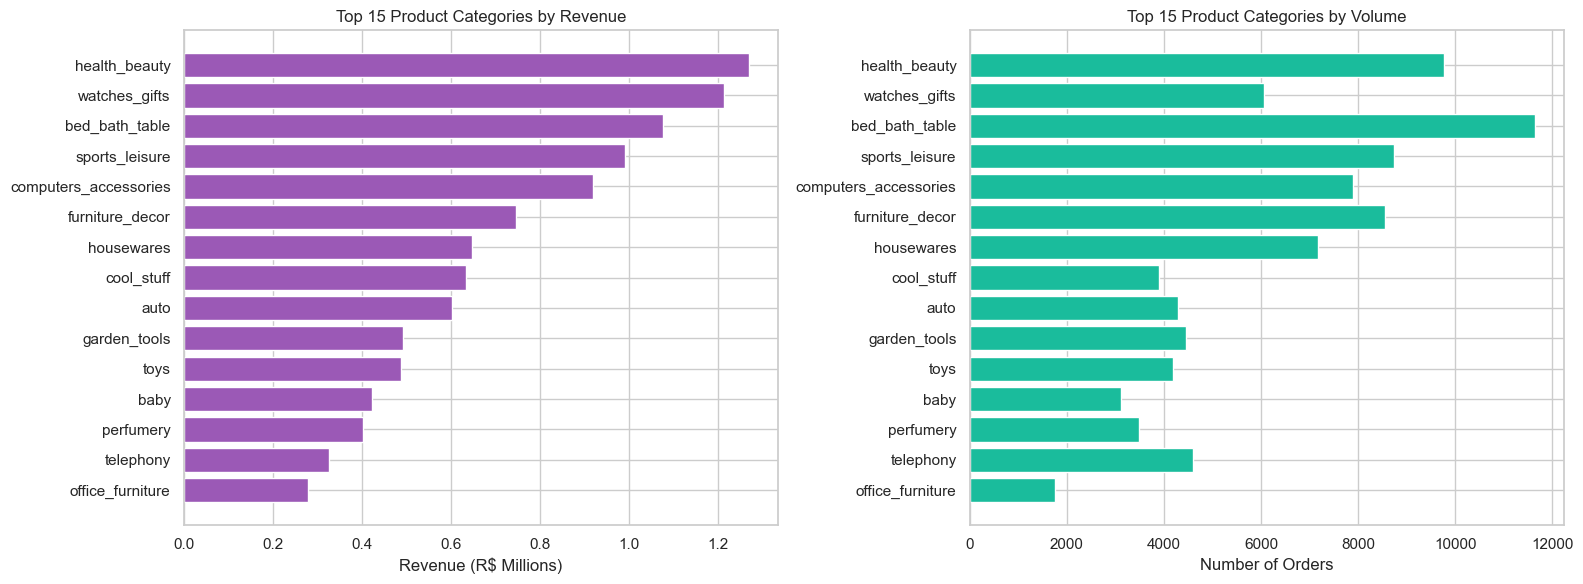

In [13]:
top_categories = (
    delivered.groupby("product_category_name_english")["price"]
    .agg(["sum", "count"])
    .sort_values("sum", ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_categories.index, top_categories["sum"] / 1e6, color="#9b59b6", edgecolor="white")
axes[0].set_xlabel("Revenue (R$ Millions)")
axes[0].set_title("Top 15 Product Categories by Revenue")
axes[0].invert_yaxis()

axes[1].barh(top_categories.index, top_categories["count"], color="#1abc9c", edgecolor="white")
axes[1].set_xlabel("Number of Orders")
axes[1].set_title("Top 15 Product Categories by Volume")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top_categories.png", bbox_inches="tight")
plt.show()

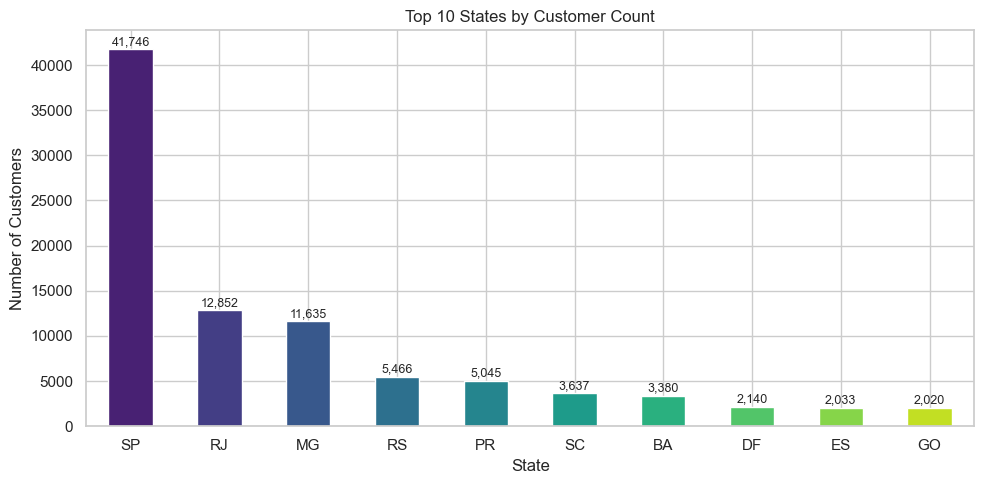

In [14]:
top_states = customers["customer_state"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
top_states.plot(kind="bar", ax=ax, color=sns.color_palette("viridis", len(top_states)), edgecolor="white")
ax.set_title("Top 10 States by Customer Count")
ax.set_xlabel("State")
ax.set_ylabel("Number of Customers")
ax.tick_params(axis="x", rotation=0)

for i, v in enumerate(top_states.values):
    ax.text(i, v + 500, f"{v:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "customer_distribution_by_state.png", bbox_inches="tight")
plt.show()

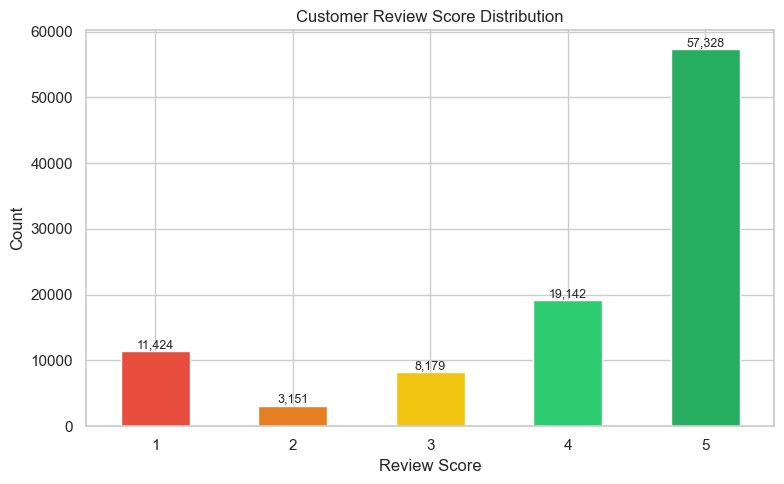


Average review score: 4.09
Median review score: 5


In [15]:
review_dist = reviews["review_score"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#e74c3c", "#e67e22", "#f1c40f", "#2ecc71", "#27ae60"]
review_dist.plot(kind="bar", ax=ax, color=colors, edgecolor="white")
ax.set_title("Customer Review Score Distribution")
ax.set_xlabel("Review Score")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=0)

for i, v in enumerate(review_dist.values):
    ax.text(i, v + 500, f"{v:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "review_score_distribution.png", bbox_inches="tight")
plt.show()

print(f"\nAverage review score: {reviews['review_score'].mean():.2f}")
print(f"Median review score: {reviews['review_score'].median():.0f}")

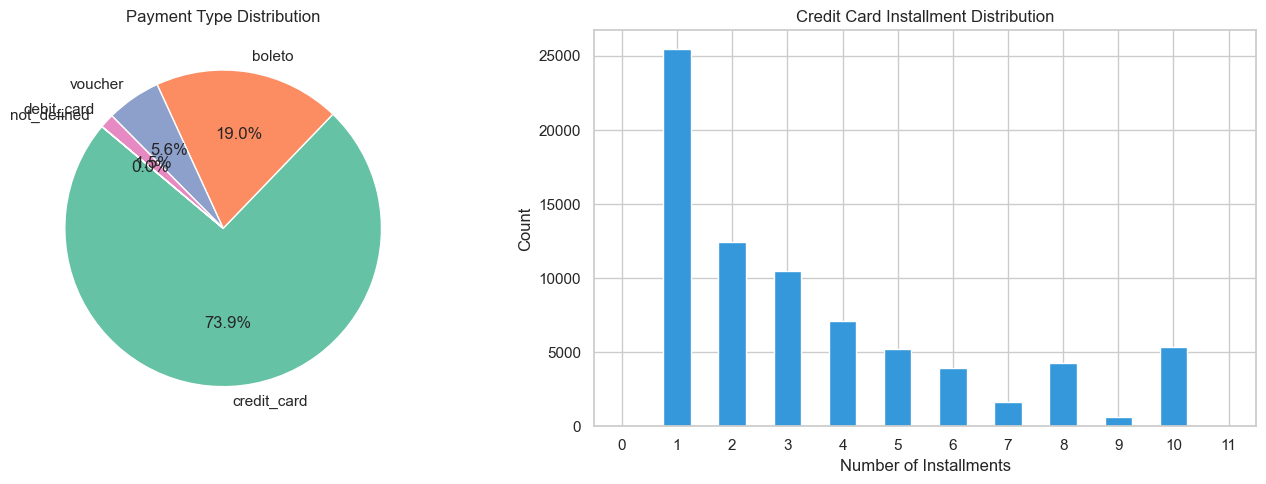

In [16]:
payment_dist = payments["payment_type"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(
    payment_dist.values,
    labels=payment_dist.index,
    autopct="%1.1f%%",
    colors=sns.color_palette("Set2", len(payment_dist)),
    startangle=140,
)
axes[0].set_title("Payment Type Distribution")

installment_dist = payments[payments["payment_type"] == "credit_card"]["payment_installments"].value_counts().sort_index().head(12)
installment_dist.plot(kind="bar", ax=axes[1], color="#3498db", edgecolor="white")
axes[1].set_title("Credit Card Installment Distribution")
axes[1].set_xlabel("Number of Installments")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "payment_analysis.png", bbox_inches="tight")
plt.show()

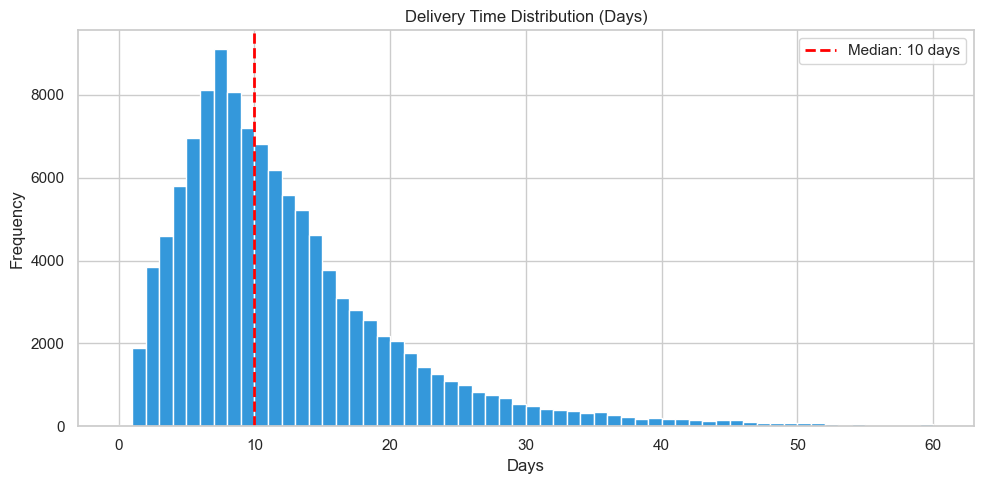


Orders delivered late: 6.5%
Average delay for late orders: 10.6 days


In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(
    delivered["delivery_days"].dropna(),
    bins=60,
    color="#3498db",
    edgecolor="white",
    range=(0, 60),
)
ax.axvline(delivered["delivery_days"].median(), color="red", linestyle="--", linewidth=2, label=f"Median: {delivered['delivery_days'].median():.0f} days")
ax.set_title("Delivery Time Distribution (Days)")
ax.set_xlabel("Days")
ax.set_ylabel("Frequency")
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "delivery_time_distribution.png", bbox_inches="tight")
plt.show()

late_pct = (delivered["delay_days"] > 0).mean() * 100
print(f"\nOrders delivered late: {late_pct:.1f}%")
print(f"Average delay for late orders: {delivered[delivered['delay_days'] > 0]['delay_days'].mean():.1f} days")

## 1.7 Correlation Heatmap

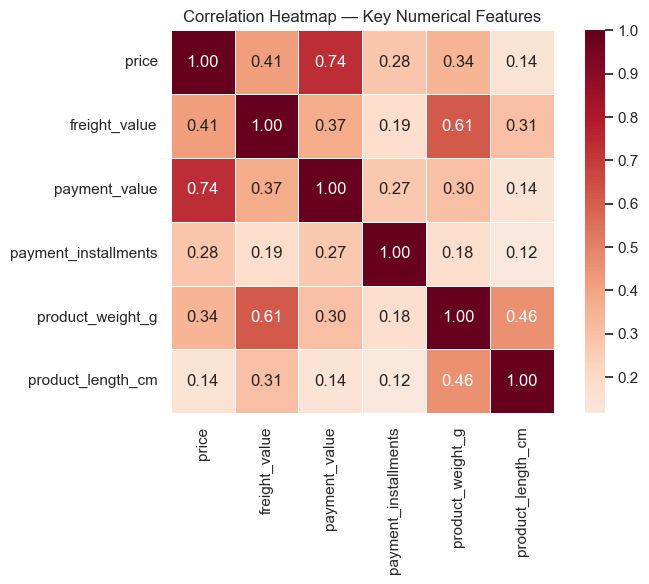

In [18]:
numeric_cols = ["price", "freight_value", "payment_value", "payment_installments", "product_weight_g", "product_length_cm"]
corr_data = delivered[numeric_cols].dropna()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_data.corr(),
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    ax=ax,
    linewidths=0.5,
)
ax.set_title("Correlation Heatmap — Key Numerical Features")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "correlation_heatmap.png", bbox_inches="tight")
plt.show()

## 1.8 Key Takeaways

| Finding | Insight |
|---|---|
| **96%+ orders delivered** | Very high fulfillment rate |
| **Credit card dominates** | ~74% of payments via credit card, heavy installment usage |
| **SP is the top state** | São Paulo has the most customers by a wide margin |
| **Average delivery ~12 days** | Room for logistics optimization |
| **4.0+ avg review score** | Generally positive, but 1-star reviews are common |
| **Price & freight correlate** | Heavier/larger items cost more to ship |

---

*Next: Module 2 — SQL Business Queries →*